In [1]:
# CELL 1 — Imports and configuration

import os
import random
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    balanced_accuracy_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")

# -----------------------------
# Reproducibility
# -----------------------------
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# -----------------------------
# Device
# -----------------------------
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("PyTorch version:", torch.__version__)
print("Device:", DEVICE)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    print("GPU not available — using CPU.")

print("Setup complete.")

PyTorch version: 2.14.0+cpu
Device: cpu
GPU not available — using CPU.
Setup complete.


In [2]:
# CELL 2 — Check EEG dataset folders

import os

DATASET_PATH = r"C:\Users\dsilv\OneDrive\Pictures\Documents\FINAL@\Dataset"   # CHANGE THIS

classes = ["F", "N", "O", "S", "Z"]

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)

    if os.path.exists(folder):
        files = [
            f for f in os.listdir(folder)
            if f.lower().endswith(".edf")
        ]
        print(f"{cls}: {len(files)} EDF files")
    else:
        print(f"{cls}: Folder not found")

print("\nCheck complete.")

F: 100 EDF files
N: 100 EDF files
O: 100 EDF files
S: 100 EDF files
Z: 100 EDF files

Check complete.


In [3]:
# CELL 3 — Test loading one EEG recording

import os
import mne

DATASET_PATH = r"C:\Users\dsilv\OneDrive\Pictures\Documents\FINAL@\Dataset"

test_file = os.path.join(DATASET_PATH, "F", "F001.edf")

raw = mne.io.read_raw_edf(test_file, preload=True, verbose=False)

print("File loaded successfully")
print("Channels:", raw.info["nchan"])
print("Sampling frequency:", raw.info["sfreq"], "Hz")
print("Duration:", raw.times[-1], "seconds")
print("Data shape:", raw.get_data().shape)

File loaded successfully
Channels: 1
Sampling frequency: 173.6101736101736 Hz
Duration: 25.920139968895803 seconds
Data shape: (1, 4501)


In [4]:
# CELL 4 — Load all EEG recordings

import os
import numpy as np
import mne

DATASET_PATH = r"C:\Users\dsilv\OneDrive\Pictures\Documents\FINAL@\Dataset"

classes = ["F", "N", "O", "S", "Z"]

signals = []
labels = []
original_classes = []

for cls in classes:
    folder = os.path.join(DATASET_PATH, cls)

    for filename in sorted(os.listdir(folder)):
        if not filename.lower().endswith(".edf"):
            continue

        filepath = os.path.join(folder, filename)

        raw = mne.io.read_raw_edf(
            filepath,
            preload=True,
            verbose=False
        )

        signal = raw.get_data()[0]

        signals.append(signal)
        original_classes.append(cls)

        # F, N, S = Epilepsy
        # O, Z = Non-Epilepsy
        if cls in ["F", "N", "S"]:
            labels.append(1)
        else:
            labels.append(0)

signals = np.array(signals, dtype=np.float32)
labels = np.array(labels, dtype=np.int64)
original_classes = np.array(original_classes)

print("Total recordings:", len(signals))
print("Signal shape:", signals.shape)
print("Labels shape:", labels.shape)

print("\nClass counts:")
for cls in classes:
    print(cls, ":", np.sum(original_classes == cls))

print("\nBinary labels:")
print("Epilepsy:", np.sum(labels == 1))
print("Non-Epilepsy:", np.sum(labels == 0))

Total recordings: 500
Signal shape: (500, 4501)
Labels shape: (500,)

Class counts:
F : 100
N : 100
O : 100
S : 100
Z : 100

Binary labels:
Epilepsy: 300
Non-Epilepsy: 200


In [5]:
# CELL 5 — Exact class-wise 80/10/10 split

import numpy as np

rng = np.random.RandomState(42)

# Required number of recordings from each class
class_counts = {
    "F": 50,
    "N": 50,
    "S": 100,
    "O": 100,
    "Z": 100
}

# Store indices for each split
train_indices = []
val_indices = []
test_indices = []

for cls, count in class_counts.items():

    # All indices belonging to this class
    cls_indices = np.where(original_classes == cls)[0]

    # Select the required number
    selected = rng.choice(
        cls_indices,
        size=count,
        replace=False
    )

    # Shuffle selected indices
    rng.shuffle(selected)

    # EXACT 80 / 10 / 10
    n_train = int(count * 0.80)
    n_val = int(count * 0.10)

    train_indices.extend(selected[:n_train])
    val_indices.extend(selected[n_train:n_train + n_val])
    test_indices.extend(selected[n_train + n_val:])


# Convert to numpy arrays
train_indices = np.array(train_indices)
val_indices = np.array(val_indices)
test_indices = np.array(test_indices)

# Shuffle each split
rng.shuffle(train_indices)
rng.shuffle(val_indices)
rng.shuffle(test_indices)

# Create datasets
X_train = signals[train_indices]
y_train = labels[train_indices]
cls_train = original_classes[train_indices]

X_val = signals[val_indices]
y_val = labels[val_indices]
cls_val = original_classes[val_indices]

X_test = signals[test_indices]
y_test = labels[test_indices]
cls_test = original_classes[test_indices]


# --------------------------------------------------
# CHECK RESULTS
# --------------------------------------------------

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

print("\nExact class distribution:")

for cls in ["F", "N", "S", "O", "Z"]:
    print(
        f"{cls} → "
        f"Train: {np.sum(cls_train == cls)} | "
        f"Validation: {np.sum(cls_val == cls)} | "
        f"Test: {np.sum(cls_test == cls)}"
    )

print("\nBinary distribution:")

print(
    "Train      → Epilepsy:", np.sum(y_train == 1),
    "| Non-Epilepsy:", np.sum(y_train == 0)
)

print(
    "Validation → Epilepsy:", np.sum(y_val == 1),
    "| Non-Epilepsy:", np.sum(y_val == 0)
)

print(
    "Test       → Epilepsy:", np.sum(y_test == 1),
    "| Non-Epilepsy:", np.sum(y_test == 0)
)

Training: (320, 4501)
Validation: (40, 4501)
Testing: (40, 4501)

Exact class distribution:
F → Train: 40 | Validation: 5 | Test: 5
N → Train: 40 | Validation: 5 | Test: 5
S → Train: 80 | Validation: 10 | Test: 10
O → Train: 80 | Validation: 10 | Test: 10
Z → Train: 80 | Validation: 10 | Test: 10

Binary distribution:
Train      → Epilepsy: 160 | Non-Epilepsy: 160
Validation → Epilepsy: 20 | Non-Epilepsy: 20
Test       → Epilepsy: 20 | Non-Epilepsy: 20


In [6]:
# CELL 6 — Normalize EEG signals

def normalize_signals(X):
    mean = np.mean(X, axis=1, keepdims=True)
    std = np.std(X, axis=1, keepdims=True)

    # Prevent division by zero
    std = np.where(std == 0, 1, std)

    return (X - mean) / std


X_train = normalize_signals(X_train)
X_val = normalize_signals(X_val)
X_test = normalize_signals(X_test)

print("Normalization complete.")

print("\nTrain mean:", np.mean(X_train))
print("Train standard deviation:", np.std(X_train))

print("\nShapes:")
print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)


Normalization complete.

Train mean: -4.1316706e-10
Train standard deviation: 1.0

Shapes:
Training: (320, 4501)
Validation: (40, 4501)
Testing: (40, 4501)


In [7]:
# CELL 7 — Prepare EEG signals for GNN

# Use 4096 samples so that:
# 4096 = 64 nodes × 64 samples

X_train = X_train[:, :4096]
X_val = X_val[:, :4096]
X_test = X_test[:, :4096]

# Reshape into graph nodes
X_train = X_train.reshape(-1, 64, 64)
X_val = X_val.reshape(-1, 64, 64)
X_test = X_test.reshape(-1, 64, 64)

print("GNN input preparation complete.")

print("\nTraining shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Testing shape:", X_test.shape)

print("\nEach recording:")
print("Nodes:", X_train.shape[1])
print("Samples per node:", X_train.shape[2])

GNN input preparation complete.

Training shape: (320, 64, 64)
Validation shape: (40, 64, 64)
Testing shape: (40, 64, 64)

Each recording:
Nodes: 64
Samples per node: 64


In [8]:
# CELL 8 — Create PyTorch DataLoaders

from torch.utils.data import TensorDataset, DataLoader

# Convert data to PyTorch tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.long)

X_val_tensor = torch.tensor(X_val, dtype=torch.float32)
y_val_tensor = torch.tensor(y_val, dtype=torch.long)

X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)

# Create datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create data loaders
train_loader = DataLoader(
    train_dataset,
    batch_size=16,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=16,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=16,
    shuffle=False
)

print("PyTorch DataLoaders created successfully.")

print("Training batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Testing batches:", len(test_loader))

PyTorch DataLoaders created successfully.
Training batches: 20
Validation batches: 3
Testing batches: 3


In [9]:
# CELL 9 — GNN Layer

import torch
import torch.nn as nn
import torch.nn.functional as F

class GNNLayer(nn.Module):

    def __init__(self, input_dim, hidden_dim):
        super().__init__()

        self.self_transform = nn.Linear(
            input_dim,
            hidden_dim
        )

        self.neighbor_transform = nn.Linear(
            input_dim,
            hidden_dim
        )

        self.update = nn.Linear(
            hidden_dim * 2,
            hidden_dim
        )

    def forward(self, x, edge_index):

        num_nodes = x.size(0)

        source = edge_index[0]
        target = edge_index[1]

        # Transform each node
        self_features = self.self_transform(x)

        # Transform neighboring nodes
        neighbor_features = self.neighbor_transform(x)

        # Aggregate neighbor information
        aggregated = torch.zeros(
            num_nodes,
            neighbor_features.size(1),
            device=x.device
        )

        aggregated.index_add_(
            0,
            target,
            neighbor_features[source]
        )

        # Calculate node degree
        degree = torch.zeros(
            num_nodes,
            device=x.device
        )

        degree.index_add_(
            0,
            target,
            torch.ones(
                source.size(0),
                device=x.device
            )
        )

        degree = degree.clamp(min=1).unsqueeze(1)

        # Mean aggregation
        aggregated = aggregated / degree

        # Combine node + neighbor information
        h = torch.cat(
            [self_features, aggregated],
            dim=1
        )

        h = F.relu(self.update(h))

        return h


print("GNN layer defined successfully.")

GNN layer defined successfully.


In [12]:
# CELL 10 — GNN + BiLSTM + BiGRU Model

class GNNBiLSTMBiGRU(nn.Module):

    def __init__(
        self,
        n_nodes=64,
        node_len=64,
        hidden=64,
        classes=2
    ):
        super().__init__()

        self.n_nodes = n_nodes
        self.node_len = node_len

        # GNN layers
        self.gnn1 = GNNLayer(
            node_len,
            64
        )

        self.gnn2 = GNNLayer(
            64,
            64
        )

        # Bidirectional LSTM
        self.bilstm = nn.LSTM(
            input_size=64,
            hidden_size=hidden,
            batch_first=True,
            bidirectional=True
        )

        # Bidirectional GRU
        self.bigru = nn.GRU(
            input_size=hidden * 2,
            hidden_size=hidden,
            batch_first=True,
            bidirectional=True
        )

        self.dropout = nn.Dropout(0.35)

        # Binary classification
        # 0 = Non-Epilepsy
        # 1 = Epilepsy
        self.classifier = nn.Linear(
            hidden * 2,
            classes
        )

        # Create graph connections
        edges = []

        # Connect neighboring nodes
        for i in range(n_nodes - 1):
            edges.append((i, i + 1))
            edges.append((i + 1, i))

        # Self connections
        for i in range(n_nodes):
            edges.append((i, i))

        edge_index = torch.tensor(
            edges,
            dtype=torch.long
        ).t().contiguous()

        self.register_buffer(
            "edge_index",
            edge_index
        )

    def forward(self, x):

        batch_size = x.size(0)

        # [batch, 64, 64]
        x = x.view(
            batch_size,
            self.n_nodes,
            self.node_len
        )

        graph_outputs = []

        # Apply GNN to each recording
        for b in range(batch_size):

            h = self.gnn1(
                x[b],
                self.edge_index
            )

            h = self.gnn2(
                h,
                self.edge_index
            )

            graph_outputs.append(h)

        h = torch.stack(
            graph_outputs,
            dim=0
        )

        # BiLSTM
        h, _ = self.bilstm(h)

        # BiGRU
        h, _ = self.bigru(h)

        # Use final time step
        h = h[:, -1, :]

        h = self.dropout(h)

        # Classification
        return self.classifier(h)


print("GNN + BiLSTM + BiGRU model defined successfully.")

GNN + BiLSTM + BiGRU model defined successfully.


In [13]:
# CELL 11 — Initialize model

import torch

device = torch.device("cpu")

model = GNNBiLSTMBiGRU(
    n_nodes=64,
    node_len=64,
    hidden=64,
    classes=2
).to(device)

print(model)

# Count trainable parameters
total_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print("\nTrainable parameters:", total_params)
print("Device:", device)

GNNBiLSTMBiGRU(
  (gnn1): GNNLayer(
    (self_transform): Linear(in_features=64, out_features=64, bias=True)
    (neighbor_transform): Linear(in_features=64, out_features=64, bias=True)
    (update): Linear(in_features=128, out_features=64, bias=True)
  )
  (gnn2): GNNLayer(
    (self_transform): Linear(in_features=64, out_features=64, bias=True)
    (neighbor_transform): Linear(in_features=64, out_features=64, bias=True)
    (update): Linear(in_features=128, out_features=64, bias=True)
  )
  (bilstm): LSTM(64, 64, batch_first=True, bidirectional=True)
  (bigru): GRU(128, 64, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.35, inplace=False)
  (classifier): Linear(in_features=128, out_features=2, bias=True)
)

Trainable parameters: 174466
Device: cpu


In [14]:
# CELL 12 — Loss function and optimizer

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=0.0005,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5
)

print("Loss function:", criterion)
print("Optimizer:", optimizer)
print("Initial learning rate:", optimizer.param_groups[0]["lr"])
print("Scheduler: ReduceLROnPlateau")

Loss function: CrossEntropyLoss()
Optimizer: AdamW (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: True
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0005
    maximize: False
    weight_decay: 0.0001
)
Initial learning rate: 0.0005
Scheduler: ReduceLROnPlateau


In [16]:

def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)

        loss = criterion(outputs, y_batch)

        loss.backward()

        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    epoch_loss = total_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():

        for X_batch, y_batch in loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)

            loss = criterion(outputs, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            predictions = torch.argmax(outputs, dim=1)

            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    epoch_loss = total_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy


print("Training and evaluation functions defined successfully.")

Training and evaluation functions defined successfully.


In [21]:
# CELL 14 — Model training

import copy

num_epochs = 40

best_val_accuracy = 0.0
best_model_state = copy.deepcopy(model.state_dict())

train_losses = []
train_accuracies = []
val_losses = []
val_accuracies = []

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = evaluate(
        model, val_loader, criterion, device
    )

    scheduler.step(val_acc)

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    if val_acc > best_val_accuracy:
        best_val_accuracy = val_acc
        best_model_state = copy.deepcopy(model.state_dict())

    print(
        f"Epoch {epoch + 1:02d}/{num_epochs} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.6f}"
    )

model.load_state_dict(best_model_state)

print("\nTraining completed.")
print(f"Best validation accuracy: {best_val_accuracy:.4f}")

Epoch 01/40 | Train Loss: 0.0946 | Train Acc: 0.9812 | Val Loss: 0.3813 | Val Acc: 0.8750 | LR: 0.000063
Epoch 02/40 | Train Loss: 0.0895 | Train Acc: 0.9844 | Val Loss: 0.3876 | Val Acc: 0.8750 | LR: 0.000063
Epoch 03/40 | Train Loss: 0.0851 | Train Acc: 0.9844 | Val Loss: 0.3943 | Val Acc: 0.8750 | LR: 0.000063
Epoch 04/40 | Train Loss: 0.0843 | Train Acc: 0.9844 | Val Loss: 0.3857 | Val Acc: 0.8750 | LR: 0.000031
Epoch 05/40 | Train Loss: 0.0824 | Train Acc: 0.9844 | Val Loss: 0.3941 | Val Acc: 0.8750 | LR: 0.000031
Epoch 06/40 | Train Loss: 0.0812 | Train Acc: 0.9844 | Val Loss: 0.3976 | Val Acc: 0.8750 | LR: 0.000031
Epoch 07/40 | Train Loss: 0.0804 | Train Acc: 0.9844 | Val Loss: 0.3957 | Val Acc: 0.8750 | LR: 0.000031
Epoch 08/40 | Train Loss: 0.0777 | Train Acc: 0.9844 | Val Loss: 0.3940 | Val Acc: 0.8750 | LR: 0.000031
Epoch 09/40 | Train Loss: 0.0778 | Train Acc: 0.9844 | Val Loss: 0.4006 | Val Acc: 0.8750 | LR: 0.000031
Epoch 10/40 | Train Loss: 0.0720 | Train Acc: 0.9844 | 

In [22]:
# CELL 15 — Final test evaluation

test_loss, test_accuracy = evaluate(
    model, test_loader, criterion, device
)

print("Test Loss:", round(test_loss, 4))
print("Test Accuracy:", round(test_accuracy, 4))

Test Loss: 0.1687
Test Accuracy: 0.95


In [23]:
# CELL 16 — Detailed test evaluation

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
    balanced_accuracy_score
)

model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)

        outputs = model(X_batch)
        predictions = torch.argmax(outputs, dim=1)

        all_predictions.extend(predictions.cpu().numpy())
        all_targets.extend(y_batch.numpy())

# Confusion matrix
cm = confusion_matrix(all_targets, all_predictions)

# Metrics
precision = precision_score(all_targets, all_predictions)
recall = recall_score(all_targets, all_predictions)
f1 = f1_score(all_targets, all_predictions)
balanced_acc = balanced_accuracy_score(all_targets, all_predictions)

# Specificity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)

print("Confusion Matrix:")
print(cm)

print("\nDetailed Metrics:")
print(f"Precision       : {precision:.4f}")
print(f"Recall/Sensitivity: {recall:.4f}")
print(f"Specificity     : {specificity:.4f}")
print(f"F1-Score        : {f1:.4f}")
print(f"Balanced Accuracy: {balanced_acc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=["Non-Epilepsy", "Epilepsy"]
    )
)

Confusion Matrix:
[[20  0]
 [ 2 18]]

Detailed Metrics:
Precision       : 1.0000
Recall/Sensitivity: 0.9000
Specificity     : 1.0000
F1-Score        : 0.9474
Balanced Accuracy: 0.9500

Classification Report:
              precision    recall  f1-score   support

Non-Epilepsy       0.91      1.00      0.95        20
    Epilepsy       1.00      0.90      0.95        20

    accuracy                           0.95        40
   macro avg       0.95      0.95      0.95        40
weighted avg       0.95      0.95      0.95        40



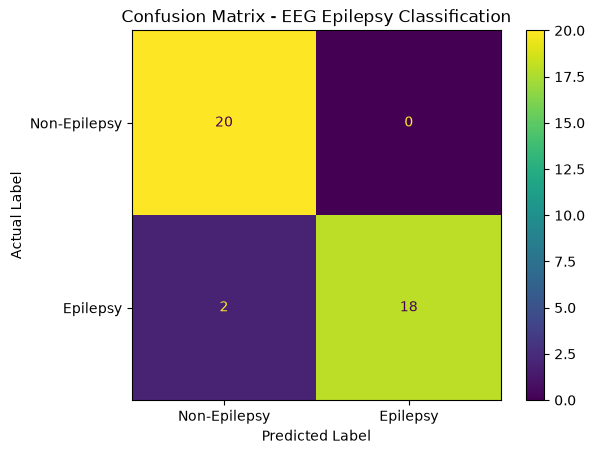

In [24]:
# CELL 17 — Confusion Matrix Visualization

import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Non-Epilepsy", "Epilepsy"]
)

disp.plot()

plt.title("Confusion Matrix - EEG Epilepsy Classification")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

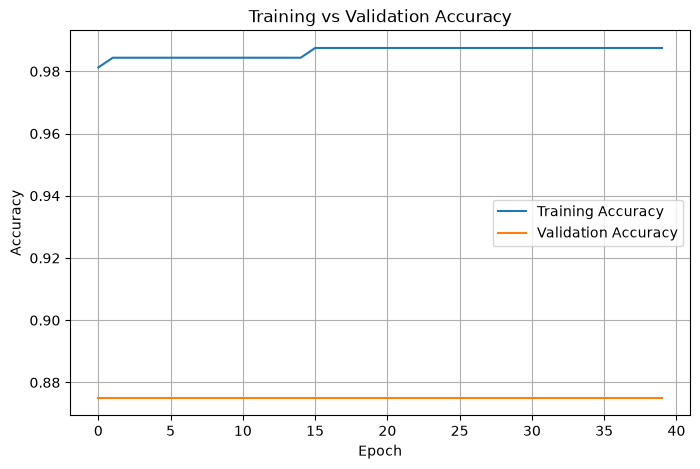

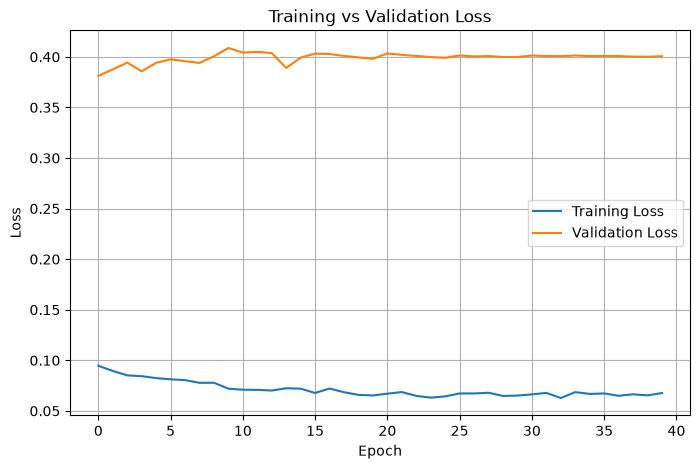

In [25]:
# CELL 18 — Training and Validation Graphs

import matplotlib.pyplot as plt

# Accuracy graph
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()


# Loss graph
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

In [26]:
# CELL 19 — Save final trained model

model_path = "EEG_Epilepsy_GNN_BiLSTM_BiGRU_30epochs.pth"

torch.save(model.state_dict(), model_path)

print("Model saved successfully.")
print("Saved as:", model_path)

Model saved successfully.
Saved as: EEG_Epilepsy_GNN_BiLSTM_BiGRU_30epochs.pth


In [27]:
# CELL 20 — ROC-AUC

from sklearn.metrics import roc_auc_score

model.eval()

all_probs = []
all_targets = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)

        outputs = model(X_batch)

        # Probability of Epilepsy
        probs = torch.softmax(outputs, dim=1)[:, 1]

        all_probs.extend(probs.cpu().numpy())
        all_targets.extend(y_batch.numpy())

roc_auc = roc_auc_score(all_targets, all_probs)

print(f"ROC-AUC: {roc_auc:.4f}")

ROC-AUC: 0.9600


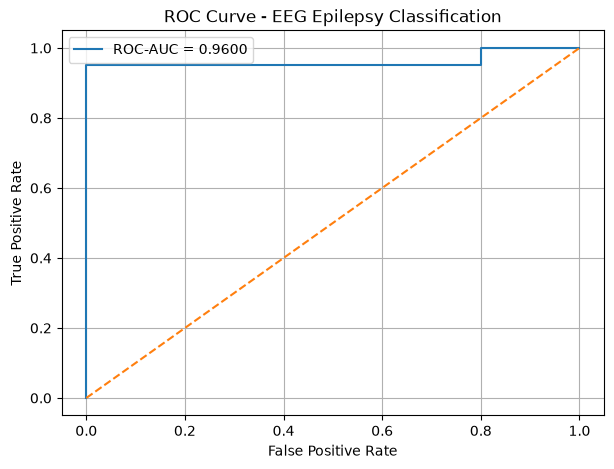

In [29]:
# CELL 21 — ROC Curve

from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

fpr, tpr, thresholds = roc_curve(all_targets, all_probs)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - EEG Epilepsy Classification")
plt.legend()
plt.grid(True)
plt.show()

In [30]:
model_path = "EEG_Epilepsy_GNN_BiLSTM_BiGRU_30epochs.pth"
torch.save(model.state_dict(), model_path)
print("Model saved successfully.")

Model saved successfully.
